In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Sequence
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle

from json_in_out import read_instanceData_from_json, read_instance_metadata_from_json
from instance_generator_final import InstanceData

In [ ]:
def _scatter_coordinates(
    ax,
    coords: dict[int, tuple[float, float]],
    marker: str,
    label: str,
    size: float,
    alpha: float = 0.85,
) -> None:
    """
    Scatter-plot a coordinate dictionary.
    """
    if not coords:
        return

    x_values = [point[0] for point in coords.values()]
    y_values = [point[1] for point in coords.values()]

    ax.scatter(
        x_values,
        y_values,
        marker=marker,
        s=size,
        label=label,
        alpha=alpha,
        edgecolors="black",
        linewidths=0.5,
    )


def _add_radius_ring(
    ax,
    radius: float,
    label: str | None = None,
    linestyle: str = "--",
    linewidth: float = 0.9,
    alpha: float = 0.65,
) -> None:
    """
    Add a circular radius marker around the city center.
    """
    ring = Circle(
        (0.0, 0.0),
        radius=radius,
        fill=False,
        linestyle=linestyle,
        linewidth=linewidth,
        alpha=alpha,
    )
    ax.add_patch(ring)

    if label is not None:
        ax.text(
            radius / 2**0.5,
            radius / 2**0.5,
            label,
            fontsize=8,
            ha="left",
            va="bottom",
            alpha=0.8,
        )


def plot_instance_network(
    instance: InstanceData,
    city_size: float,
    grid_cell_size: float,
    waste_gen_density: float,
    incinerator_radius_min: float = 10.0,
    incinerator_radius_max: float = 60.0,
    landfill_radius_min: float = 40.0,
    landfill_radius_max: float = 120.0,
    cement_radius_min: float = 80.0,
    cement_radius_max: float = 320.0,
    show_rings: bool = True,
    annotate_facilities: bool = False,
    title: str = "Synthetic Waste Management Network",
    save_path: str | Path | None = None,
    show: bool = True,
) -> None:
    """
    Plot the generated synthetic network.

    Parameters
    ----------
    instance:
        Generated InstanceData object containing node coordinates.

    city_size:
        Side length of the square urban area in km.

    grid_cell_size:
        Side length of each generation-grid cell in km.

    waste_gen_density:
        Annual waste generation density in t/(km² year).

    incinerator_radius_min, incinerator_radius_max:
        Inner and outer radius of the incinerator placement ring.

    landfill_radius_min, landfill_radius_max:
        Inner and outer radius of the landfill placement ring.

    cement_radius_min, cement_radius_max:
        Inner and outer radius of the cement-kiln placement ring.

    show_rings:
        If True, show min/max placement rings.

    annotate_facilities:
        If True, annotate non-generation facilities by index.

    title:
        Plot title.

    save_path:
        Optional path to save the figure.

    show:
        If True, display the plot.
    """
    fig, ax = plt.subplots(figsize=(10, 10))

    half_city = city_size / 2.0

    # City boundary
    city_boundary = Rectangle(
        (-half_city, -half_city),
        city_size,
        city_size,
        fill=False,
        linewidth=1.2,
        linestyle="-",
        label="City boundary",
    )
    ax.add_patch(city_boundary)

    # Optional radius rings
    if show_rings:
        _add_radius_ring(ax, incinerator_radius_min, "I min")
        _add_radius_ring(ax, incinerator_radius_max, "I max")
        _add_radius_ring(ax, landfill_radius_min, "L min")
        _add_radius_ring(ax, landfill_radius_max, "L max")
        _add_radius_ring(ax, cement_radius_min, "C min")
        _add_radius_ring(ax, cement_radius_max, "C max")

    # Node sets
    _scatter_coordinates(
        ax,
        instance.G_coords,
        marker=".",
        label=f"Generation spots G ({instance.G_max})",
        size=35,
        alpha=0.65,
    )
    _scatter_coordinates(
        ax,
        instance.S_coords,
        marker="s",
        label=f"Transfer stations S ({instance.S_max})",
        size=85,
    )
    _scatter_coordinates(
        ax,
        instance.I_coords,
        marker="^",
        label=f"Incinerators I ({instance.I_max})",
        size=95,
    )
    _scatter_coordinates(
        ax,
        instance.L_coords,
        marker="D",
        label=f"Landfills L ({instance.L_max})",
        size=95,
    )
    _scatter_coordinates(
        ax,
        instance.C_coords,
        marker="X",
        label=f"Cement kilns C ({instance.C_max})",
        size=110,
    )

    if annotate_facilities:
        for prefix, coords in [
            ("S", instance.S_coords),
            ("I", instance.I_coords),
            ("L", instance.L_coords),
            ("C", instance.C_coords),
        ]:
            for idx, (x_coord, y_coord) in coords.items():
                ax.text(
                    x_coord,
                    y_coord,
                    f" {prefix}{idx}",
                    fontsize=8,
                    ha="left",
                    va="center",
                )

    # Parameter text box
    parameter_text = (
        f"City size: {city_size:.1f} km × {city_size:.1f} km\n"
        f"Grid cell size: {grid_cell_size:.1f} km × {grid_cell_size:.1f} km\n"
        f"Waste density: {waste_gen_density:,.0f} t/(km²·year)\n"
        f"Generated waste: {instance.Q_gen_total:,.0f} t/year\n"
        f"Incinerator radii: {incinerator_radius_min:.0f}–{incinerator_radius_max:.0f} km\n"
        f"Landfill radii: {landfill_radius_min:.0f}–{landfill_radius_max:.0f} km\n"
        f"Cement-kiln radii: {cement_radius_min:.0f}–{cement_radius_max:.0f} km"
    )

    ax.text(
        0.02,
        0.98,
        parameter_text,
        transform=ax.transAxes,
        fontsize=9,
        va="top",
        ha="left",
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "alpha": 0.85,
            "edgecolor": "gray",
        },
    )

    # Axis formatting
    max_extent = max(
        cement_radius_max,
        landfill_radius_max,
        incinerator_radius_max,
        half_city,
    )
    margin = 0.08 * max_extent

    ax.set_xlim(-max_extent - margin, max_extent + margin)
    ax.set_ylim(-max_extent - margin, max_extent + margin)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("x-coordinate [km]")
    ax.set_ylabel("y-coordinate [km]")
    ax.set_title(title)
    ax.grid(True, linewidth=0.4, alpha=0.35)
    ax.legend(loc="lower left", fontsize=8, framealpha=0.9)

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

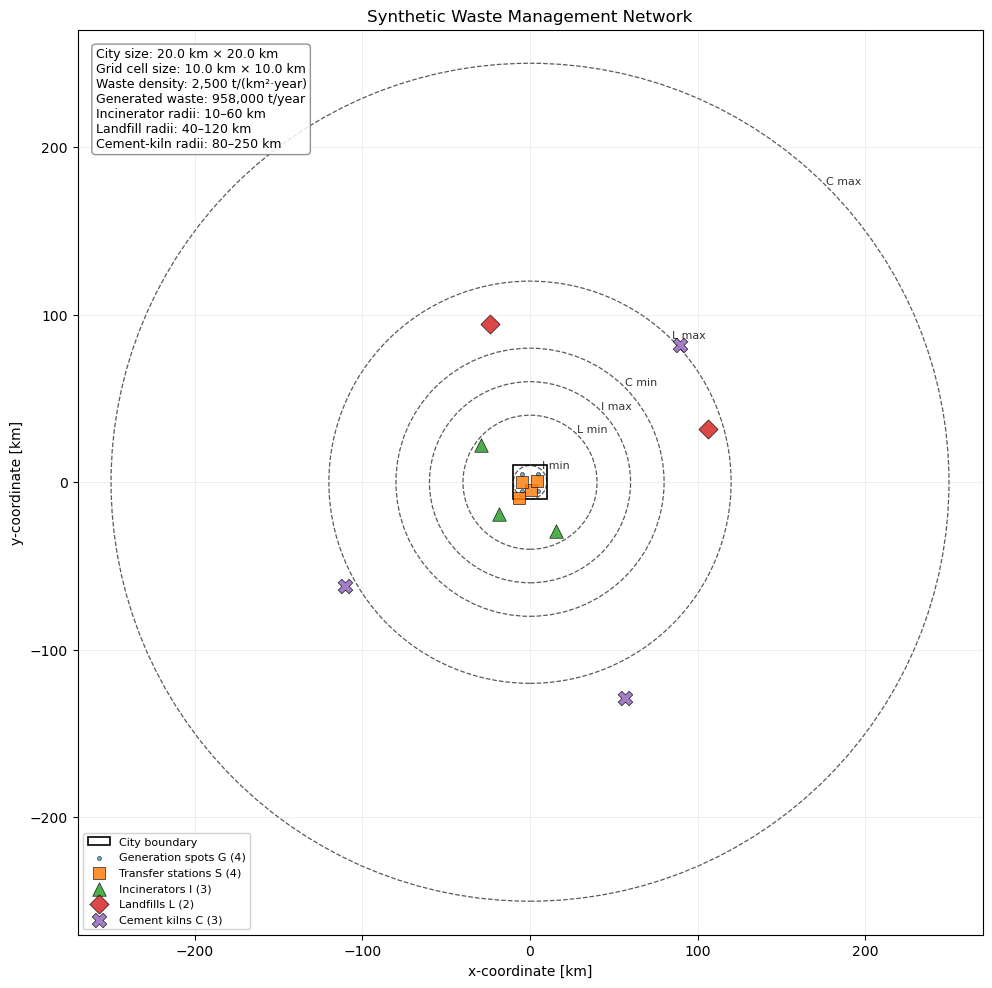

In [15]:
# Find project root (folder that contains "Instances")
cwd = Path.cwd()
repo_root = next((p for p in [cwd, *cwd.parents] if (p / "Instances").exists()), None)
if repo_root is None:
    raise FileNotFoundError("Could not find 'Instances' folder from current working directory.")

json_path = repo_root / "Instances" / "generated_instances" / "instance_s_base_001.json"

if not json_path.exists():
    raise FileNotFoundError(f"JSON file not found: {json_path}")

instance = read_instanceData_from_json(json_path)
metadata = read_instance_metadata_from_json(json_path)

plot_instance_network(
    instance=instance,
    city_size=metadata["network_settings"]["city_size"],
    grid_cell_size=metadata["network_settings"]["grid_cell_size"],
    waste_gen_density=metadata["network_settings"]["waste_gen_density"],
    incinerator_radius_min=metadata["network_settings"]["incinerator_radius_min"],
    incinerator_radius_max=metadata["network_settings"]["incinerator_radius_max"],
    landfill_radius_min=metadata["network_settings"]["landfill_radius_min"],
    landfill_radius_max=metadata["network_settings"]["landfill_radius_max"],
    cement_radius_min=metadata["network_settings"]["cement_radius_min"],
    cement_radius_max=metadata["network_settings"]["cement_radius_max"],
)

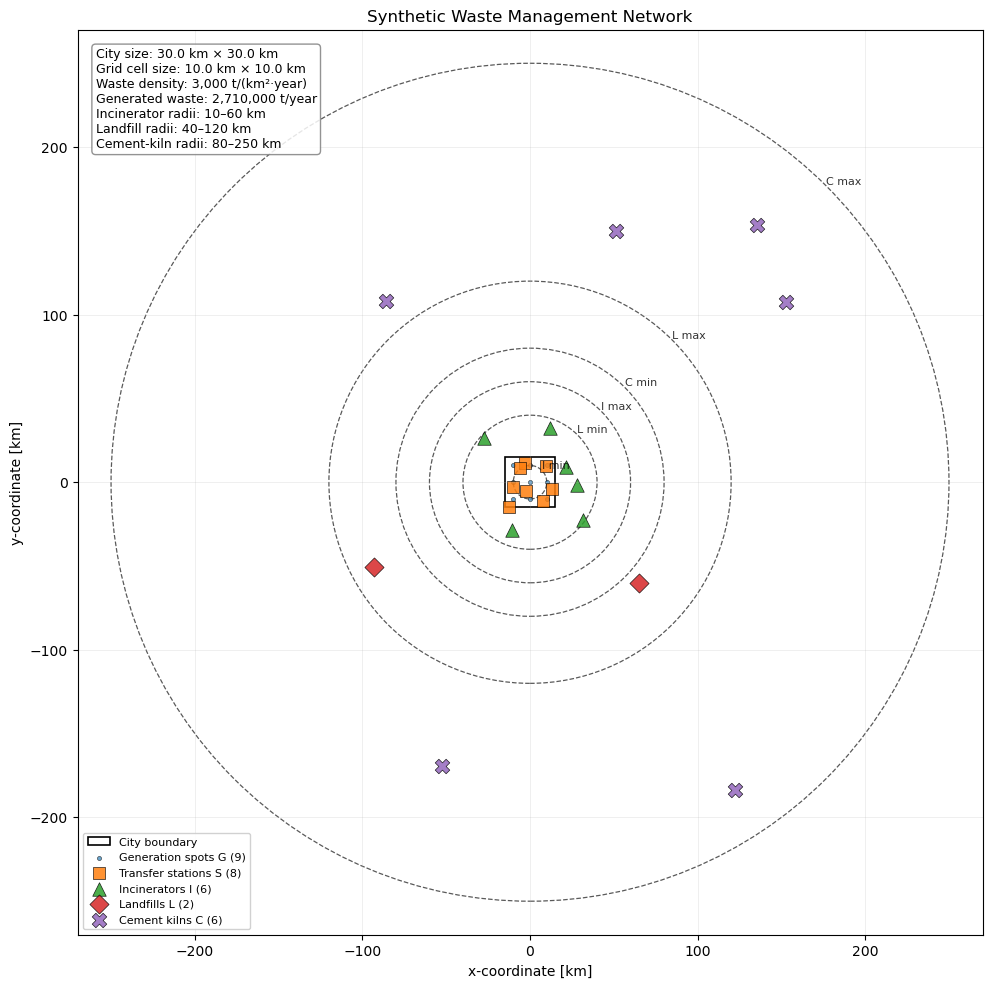

In [10]:
instance = read_instanceData_from_json(json_path)
metadata = read_instance_metadata_from_json(json_path)

plot_instance_network(
    instance=instance,
    city_size=metadata["network_settings"]["city_size"],
    grid_cell_size=metadata["network_settings"]["grid_cell_size"],
    waste_gen_density=metadata["network_settings"]["waste_gen_density"],
    incinerator_radius_min=metadata["network_settings"]["incinerator_radius_min"],
    incinerator_radius_max=metadata["network_settings"]["incinerator_radius_max"],
    landfill_radius_min=metadata["network_settings"]["landfill_radius_min"],
    landfill_radius_max=metadata["network_settings"]["landfill_radius_max"],
    cement_radius_min=metadata["network_settings"]["cement_radius_min"],
    cement_radius_max=metadata["network_settings"]["cement_radius_max"],
)

In [27]:
def _scatter_coordinates(
    ax,
    coords: dict[int, tuple[float, float]],
    marker: str,
    label: str,
    size: float,
    alpha: float = 0.85,
) -> None:
    """
    Scatter-plot a coordinate dictionary.
    """
    if not coords:
        return

    x_values = [point[0] for point in coords.values()]
    y_values = [point[1] for point in coords.values()]

    ax.scatter(
        x_values,
        y_values,
        marker=marker,
        s=size,
        label=label,
        alpha=alpha,
        edgecolors="black",
        linewidths=0.5,
    )


def _add_radius_ring(
    ax,
    radius: float,
    label: str | None = None,
    linestyle: str = "--",
    linewidth: float = 0.9,
    alpha: float = 0.65,
) -> None:
    """
    Add a circular radius marker around the city center.
    """
    ring = Circle(
        (0.0, 0.0),
        radius=radius,
        fill=False,
        linestyle=linestyle,
        linewidth=linewidth,
        alpha=alpha,
    )
    ax.add_patch(ring)

    if label is not None:
        ax.text(
            radius / 2**0.5,
            radius / 2**0.5,
            label,
            fontsize=8,
            ha="left",
            va="bottom",
            alpha=0.8,
        )


def plot_instance_network_rectangle(
    instance: InstanceData,
    city_size_x: float,
    city_size_y: float,
    grid_cell_size: float,
    waste_gen_density: float,
    incinerator_radius_min: float = 10.0,
    incinerator_radius_max: float = 60.0,
    landfill_radius_min: float = 40.0,
    landfill_radius_max: float = 120.0,
    cement_radius_min: float = 80.0,
    cement_radius_max: float = 320.0,
    show_rings: bool = True,
    annotate_facilities: bool = False,
    title: str = "Synthetic Waste Management Network",
    save_path: str | Path | None = None,
    show: bool = True,
) -> None:
    """
    Plot the generated synthetic network.

    Parameters
    ----------
    instance:
        Generated InstanceData object containing node coordinates.

    city_size:
        Side length of the square urban area in km.

    grid_cell_size:
        Side length of each generation-grid cell in km.

    waste_gen_density:
        Annual waste generation density in t/(km² year).

    incinerator_radius_min, incinerator_radius_max:
        Inner and outer radius of the incinerator placement ring.

    landfill_radius_min, landfill_radius_max:
        Inner and outer radius of the landfill placement ring.

    cement_radius_min, cement_radius_max:
        Inner and outer radius of the cement-kiln placement ring.

    show_rings:
        If True, show min/max placement rings.

    annotate_facilities:
        If True, annotate non-generation facilities by index.

    title:
        Plot title.

    save_path:
        Optional path to save the figure.

    show:
        If True, display the plot.
    """
    fig, ax = plt.subplots(figsize=(10, 10))

    half_city_x = city_size_x / 2.0
    half_city_y = city_size_y / 2.0

    # City boundary
    city_boundary = Rectangle(
        (-half_city_x, -half_city_y),
        city_size_x,
        city_size_y,
        fill=False,
        linewidth=1.2,
        linestyle="-",
        label="City boundary",
    )
    ax.add_patch(city_boundary)

    # Optional radius rings
    if show_rings:
        _add_radius_ring(ax, incinerator_radius_min, "I min")
        _add_radius_ring(ax, incinerator_radius_max, "I max")
        _add_radius_ring(ax, landfill_radius_min, "L min")
        _add_radius_ring(ax, landfill_radius_max, "L max")
        _add_radius_ring(ax, cement_radius_min, "C min")
        _add_radius_ring(ax, cement_radius_max, "C max")

    # Node sets
    _scatter_coordinates(
        ax,
        instance.G_coords,
        marker=".",
        label=f"Generation spots G ({instance.G_max})",
        size=35,
        alpha=0.65,
    )
    _scatter_coordinates(
        ax,
        instance.S_coords,
        marker="s",
        label=f"Transfer stations S ({instance.S_max})",
        size=85,
    )
    _scatter_coordinates(
        ax,
        instance.I_coords,
        marker="^",
        label=f"Incinerators I ({instance.I_max})",
        size=95,
    )
    _scatter_coordinates(
        ax,
        instance.L_coords,
        marker="D",
        label=f"Landfills L ({instance.L_max})",
        size=95,
    )
    _scatter_coordinates(
        ax,
        instance.C_coords,
        marker="X",
        label=f"Cement kilns C ({instance.C_max})",
        size=110,
    )

    if annotate_facilities:
        for prefix, coords in [
            ("S", instance.S_coords),
            ("I", instance.I_coords),
            ("L", instance.L_coords),
            ("C", instance.C_coords),
        ]:
            for idx, (x_coord, y_coord) in coords.items():
                ax.text(
                    x_coord,
                    y_coord,
                    f" {prefix}{idx}",
                    fontsize=8,
                    ha="left",
                    va="center",
                )

    # Parameter text box
    parameter_text = (
        f"City size: {city_size_x:.1f} km × {city_size_y:.1f} km\n"
        f"Grid cell size: {grid_cell_size:.1f} km × {grid_cell_size:.1f} km\n"
        f"Waste density: {waste_gen_density:,.0f} t/(km²·year)\n"
        f"Generated waste: {instance.Q_gen_total:,.0f} t/year\n"
        f"Incinerator radii: {incinerator_radius_min:.0f}–{incinerator_radius_max:.0f} km\n"
        f"Landfill radii: {landfill_radius_min:.0f}–{landfill_radius_max:.0f} km\n"
        f"Cement-kiln radii: {cement_radius_min:.0f}–{cement_radius_max:.0f} km"
    )

    ax.text(
        0.02,
        0.98,
        parameter_text,
        transform=ax.transAxes,
        fontsize=9,
        va="top",
        ha="left",
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "alpha": 0.85,
            "edgecolor": "gray",
        },
    )

    # Axis formatting
    max_extent = max(
        cement_radius_max,
        landfill_radius_max,
        incinerator_radius_max,
        half_city_x,
        half_city_y,
    )
    margin = 0.08 * max_extent

    ax.set_xlim(-max_extent - margin, max_extent + margin)
    ax.set_ylim(-max_extent - margin, max_extent + margin)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("x-coordinate [km]")
    ax.set_ylabel("y-coordinate [km]")
    ax.set_title(title)
    ax.grid(True, linewidth=0.4, alpha=0.35)
    ax.legend(loc="lower left", fontsize=8, framealpha=0.9)

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

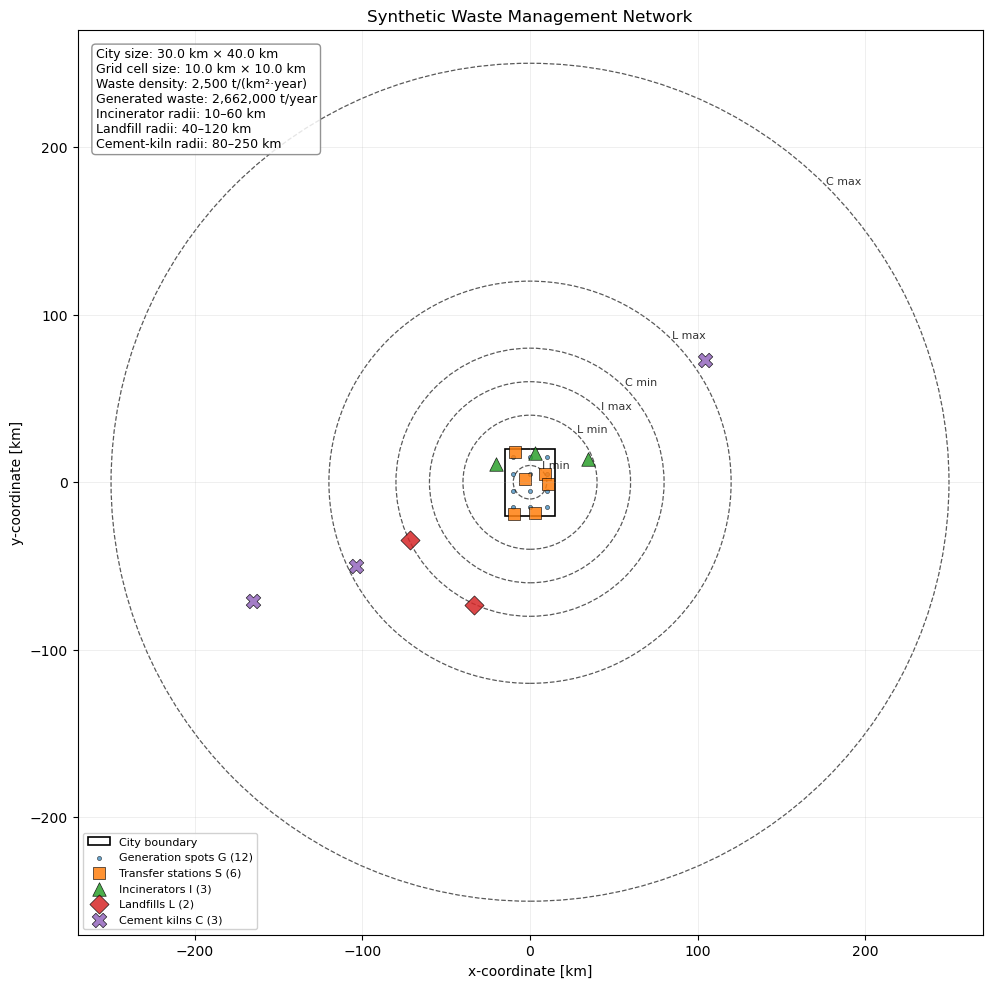

In [28]:
json_path = repo_root / "Instances" / "generated_instances" / "instance_med_baseline_001.json"

instance = read_instanceData_from_json(json_path)
metadata = read_instance_metadata_from_json(json_path)

plot_instance_network_rectangle(
    instance=instance,
    city_size_x=metadata["network_settings"]["city_size_x"],
    city_size_y=metadata["network_settings"]["city_size_y"],
    grid_cell_size=metadata["network_settings"]["grid_cell_size"],
    waste_gen_density=metadata["network_settings"]["waste_gen_density"],
    incinerator_radius_min=metadata["network_settings"]["incinerator_radius_min"],
    incinerator_radius_max=metadata["network_settings"]["incinerator_radius_max"],
    landfill_radius_min=metadata["network_settings"]["landfill_radius_min"],
    landfill_radius_max=metadata["network_settings"]["landfill_radius_max"],
    cement_radius_min=metadata["network_settings"]["cement_radius_min"],
    cement_radius_max=metadata["network_settings"]["cement_radius_max"],
)

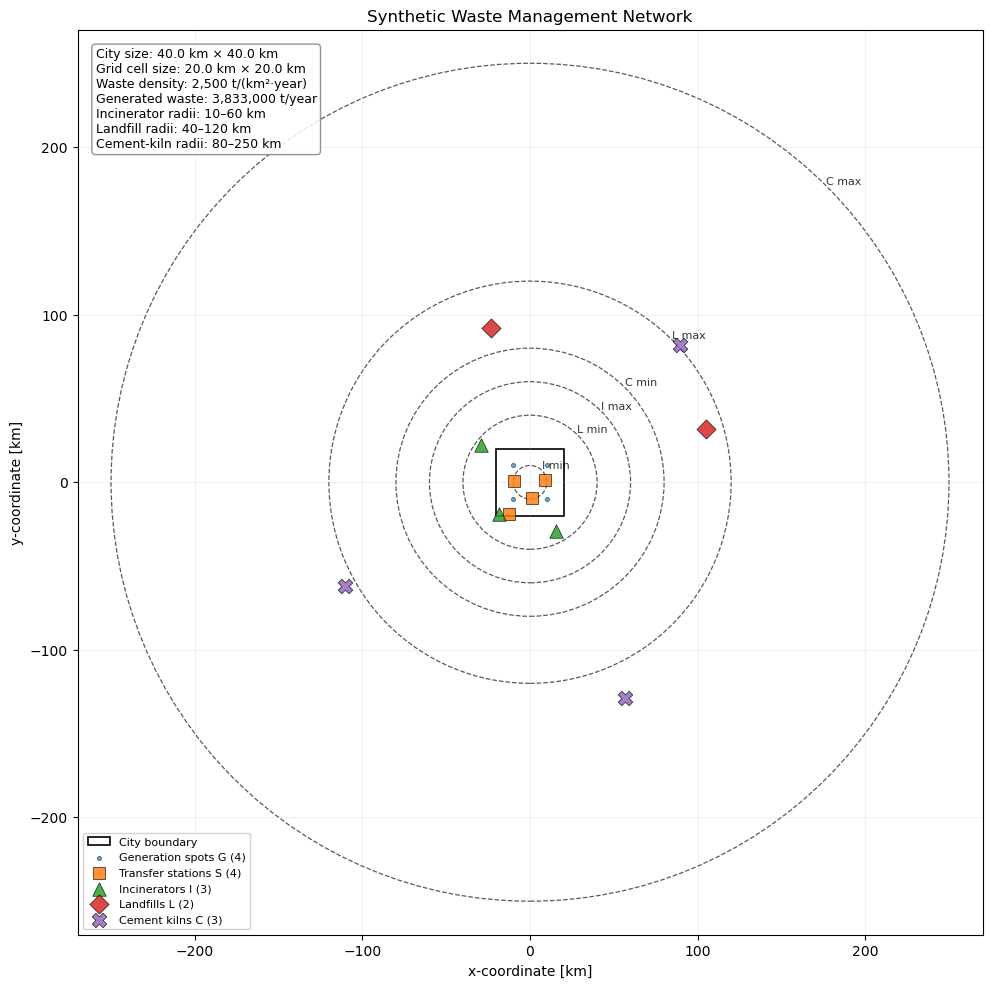

In [36]:
json_path = repo_root / "Instances" / "generated_instances" / "small" / "instance_s_base_001.json"

instance = read_instanceData_from_json(json_path)
metadata = read_instance_metadata_from_json(json_path)

plot_instance_network_rectangle(
    instance=instance,
    city_size_x=metadata["network_settings"]["city_size_x"],
    city_size_y=metadata["network_settings"]["city_size_y"],
    grid_cell_size=metadata["network_settings"]["grid_cell_size"],
    waste_gen_density=metadata["network_settings"]["waste_gen_density"],
    incinerator_radius_min=metadata["network_settings"]["incinerator_radius_min"],
    incinerator_radius_max=metadata["network_settings"]["incinerator_radius_max"],
    landfill_radius_min=metadata["network_settings"]["landfill_radius_min"],
    landfill_radius_max=metadata["network_settings"]["landfill_radius_max"],
    cement_radius_min=metadata["network_settings"]["cement_radius_min"],
    cement_radius_max=metadata["network_settings"]["cement_radius_max"],
)

In [29]:
def _scatter_coordinates_color(
    ax,
    coords: dict[int, tuple[float, float]],
    marker: str,
    label: str,
    size: float,
    color: str,
    alpha: float = 0.85,
    zorder: int = 3,
) -> None:
    """
    Scatter-plot a coordinate dictionary.
    """
    if not coords:
        return

    x_values = [point[0] for point in coords.values()]
    y_values = [point[1] for point in coords.values()]

    ax.scatter(
        x_values,
        y_values,
        marker=marker,
        s=size,
        label=label,
        color=color,
        alpha=alpha,
        edgecolors="black",
        linewidths=0.5,
        zorder=zorder,
    )

In [33]:
from matplotlib.patches import Circle


def _add_radius_annulus(
    ax,
    radius_min: float,
    radius_max: float,
    color: str,
    alpha: float = 0.1,
    boundary_alpha: float = 0.45,
    boundary_linewidth: float = 0.8,
    boundary_linestyle: str = "--",
    zorder: int = 0,
) -> None:
    """
    Highlight the area between two circular placement radii.

    The annulus is drawn as a filled outer circle plus a white inner circle.
    This is simple and visually robust for diagnostic plots.
    """
    if radius_min < 0:
        raise ValueError("radius_min must be non-negative.")
    if radius_min > radius_max:
        raise ValueError("radius_min must be smaller than or equal to radius_max.")

    outer_fill = Circle(
        (0.0, 0.0),
        radius_max,
        facecolor=color,
        edgecolor="none",
        alpha=alpha,
        zorder=zorder,
    )
    ax.add_patch(outer_fill)

    if radius_min > 0:
        inner_cutout = Circle(
            (0.0, 0.0),
            radius_min,
            facecolor="white",
            edgecolor="none",
            alpha=1.0,
            zorder=zorder + 0.1,
        )
        ax.add_patch(inner_cutout)

    # Boundary circles, without text labels
    for radius in [radius_min, radius_max]:
        boundary = Circle(
            (0.0, 0.0),
            radius,
            fill=False,
            edgecolor=color,
            linestyle=boundary_linestyle,
            linewidth=boundary_linewidth,
            alpha=boundary_alpha,
            zorder=zorder + 0.2,
        )
        ax.add_patch(boundary)

In [31]:
def plot_instance_network_rectangle_new(
    instance: InstanceData,
    city_size_x: float,
    city_size_y: float,
    grid_cell_size: float,
    waste_gen_density: float,
    incinerator_radius_min: float = 10.0,
    incinerator_radius_max: float = 60.0,
    landfill_radius_min: float = 40.0,
    landfill_radius_max: float = 120.0,
    cement_radius_min: float = 80.0,
    cement_radius_max: float = 320.0,
    show_rings: bool = True,
    annotate_facilities: bool = False,
    title: str = "Synthetic Waste Management Network",
    save_path: str | Path | None = None,
    show: bool = True,
) -> None:
    """
    Plot the generated synthetic network.

    Parameters
    ----------
    instance:
        Generated InstanceData object containing node coordinates.

    city_size:
        Side length of the square urban area in km.

    grid_cell_size:
        Side length of each generation-grid cell in km.

    waste_gen_density:
        Annual waste generation density in t/(km² year).

    incinerator_radius_min, incinerator_radius_max:
        Inner and outer radius of the incinerator placement ring.

    landfill_radius_min, landfill_radius_max:
        Inner and outer radius of the landfill placement ring.

    cement_radius_min, cement_radius_max:
        Inner and outer radius of the cement-kiln placement ring.

    show_rings:
        If True, show min/max placement rings.

    annotate_facilities:
        If True, annotate non-generation facilities by index.

    title:
        Plot title.

    save_path:
        Optional path to save the figure.

    show:
        If True, display the plot.
    """
    fig, ax = plt.subplots(figsize=(10, 10))

    half_city_x = city_size_x / 2.0
    half_city_y = city_size_y / 2.0

    # City boundary
    city_boundary = Rectangle(
        (-half_city_x, -half_city_y),
        city_size_x,
        city_size_y,
        fill=False,
        linewidth=1.2,
        linestyle="-",
        label="City boundary",
    )
    ax.add_patch(city_boundary)

    # Visual colours
    color_g = "tab:blue"
    color_s = "tab:orange"
    color_i = "tab:green"
    color_l = "tab:red"
    color_c = "tab:purple"

    # Optional radius annuli
    if show_rings:
        _add_radius_annulus(
            ax,
            radius_min=incinerator_radius_min,
            radius_max=incinerator_radius_max,
            color=color_i,
            alpha=0.05,
            zorder=0,
        )
        _add_radius_annulus(
            ax,
            radius_min=landfill_radius_min,
            radius_max=landfill_radius_max,
            color=color_l,
            alpha=0.05,
            zorder=0,
        )
        _add_radius_annulus(
            ax,
            radius_min=cement_radius_min,
            radius_max=cement_radius_max,
            color=color_c,
            alpha=0.05,
            zorder=0,
        )

    # Draw non-generation facilities first
    _scatter_coordinates_color(
        ax,
        instance.S_coords,
        marker="s",
        label=f"Transfer stations S ({instance.S_max})",
        size=85,
        color=color_s,
        alpha=0.90,
        zorder=4,
    )
    _scatter_coordinates_color(
        ax,
        instance.I_coords,
        marker="^",
        label=f"Incinerators I ({instance.I_max})",
        size=95,
        color=color_i,
        alpha=0.90,
        zorder=5,
    )
    _scatter_coordinates_color(
        ax,
        instance.L_coords,
        marker="D",
        label=f"Landfills L ({instance.L_max})",
        size=95,
        color=color_l,
        alpha=0.90,
        zorder=5,
    )
    _scatter_coordinates_color(
        ax,
        instance.C_coords,
        marker="X",
        label=f"Cement kilns C ({instance.C_max})",
        size=110,
        color=color_c,
        alpha=0.90,
        zorder=5,
    )

    # Draw generation spots last so they are visible on top
    _scatter_coordinates_color(
        ax,
        instance.G_coords,
        marker=".",
        label=f"Generation spots G ({instance.G_max})",
        size=45,
        color=color_g,
        alpha=0.95,
        zorder=10,
    )

    if annotate_facilities:
        for prefix, coords in [
            ("S", instance.S_coords),
            ("I", instance.I_coords),
            ("L", instance.L_coords),
            ("C", instance.C_coords),
        ]:
            for idx, (x_coord, y_coord) in coords.items():
                ax.text(
                    x_coord,
                    y_coord,
                    f" {prefix}{idx}",
                    fontsize=8,
                    ha="left",
                    va="center",
                )

    # Parameter text box
    parameter_text = (
        f"City size: {city_size_x:.1f} km × {city_size_y:.1f} km\n"
        f"Grid cell size: {grid_cell_size:.1f} km × {grid_cell_size:.1f} km\n"
        f"Waste density: {waste_gen_density:,.0f} t/(km²·year)\n"
        f"Generated waste: {instance.Q_gen_total:,.0f} t/year\n"
        f"Incinerator radii: {incinerator_radius_min:.0f}–{incinerator_radius_max:.0f} km\n"
        f"Landfill radii: {landfill_radius_min:.0f}–{landfill_radius_max:.0f} km\n"
        f"Cement-kiln radii: {cement_radius_min:.0f}–{cement_radius_max:.0f} km"
    )

    ax.text(
        0.02,
        0.98,
        parameter_text,
        transform=ax.transAxes,
        fontsize=9,
        va="top",
        ha="left",
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "alpha": 0.85,
            "edgecolor": "gray",
        },
    )

    # Axis formatting
    max_extent = max(
        cement_radius_max,
        landfill_radius_max,
        incinerator_radius_max,
        half_city_x,
        half_city_y,
    )
    margin = 0.08 * max_extent

    ax.set_xlim(-max_extent - margin, max_extent + margin)
    ax.set_ylim(-max_extent - margin, max_extent + margin)
    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("x-coordinate [km]")
    ax.set_ylabel("y-coordinate [km]")
    ax.set_title(title)
    ax.grid(True, linewidth=0.4, alpha=0.35)
    ax.legend(loc="lower left", fontsize=8, framealpha=0.9)

    fig.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if show:
        plt.show()
    else:
        plt.close(fig)

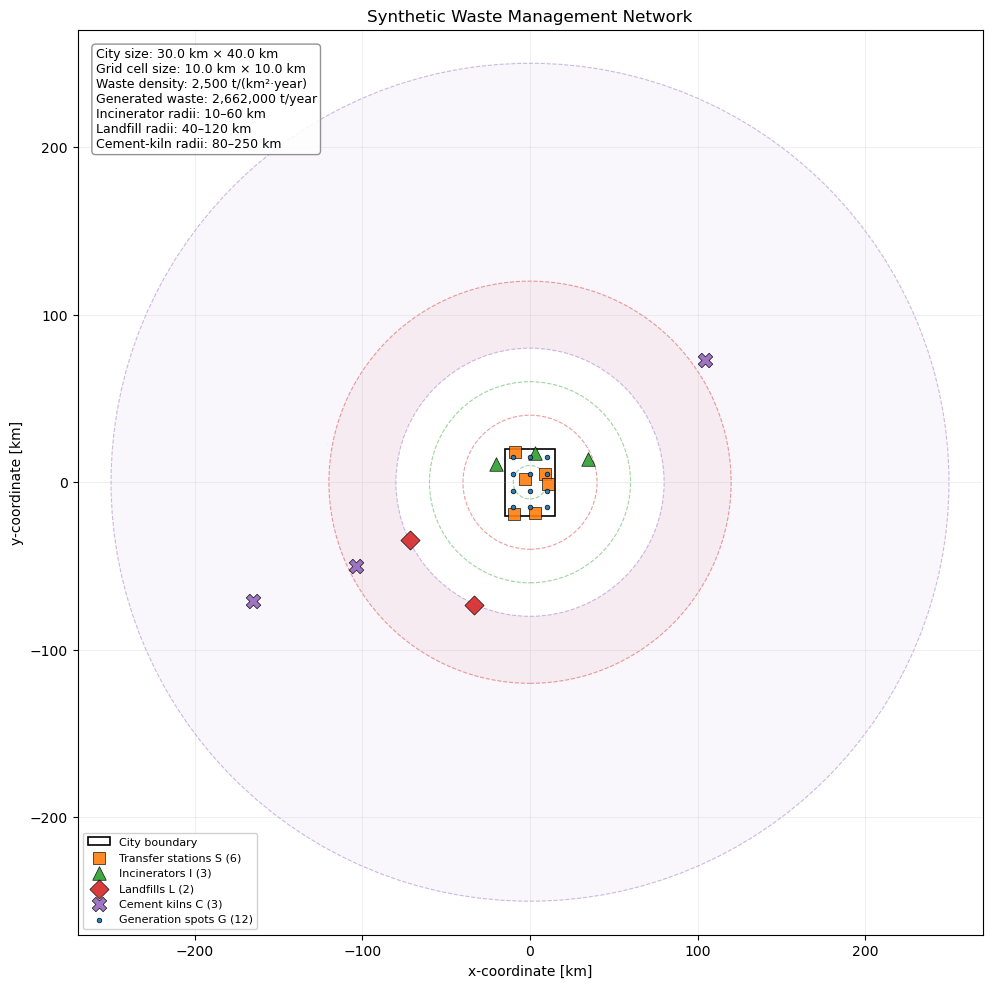

In [34]:
json_path = repo_root / "Instances" / "generated_instances" / "instance_med_baseline_001.json"

instance = read_instanceData_from_json(json_path)
metadata = read_instance_metadata_from_json(json_path)

plot_instance_network_rectangle_new(
    instance=instance,
    city_size_x=metadata["network_settings"]["city_size_x"],
    city_size_y=metadata["network_settings"]["city_size_y"],
    grid_cell_size=metadata["network_settings"]["grid_cell_size"],
    waste_gen_density=metadata["network_settings"]["waste_gen_density"],
    incinerator_radius_min=metadata["network_settings"]["incinerator_radius_min"],
    incinerator_radius_max=metadata["network_settings"]["incinerator_radius_max"],
    landfill_radius_min=metadata["network_settings"]["landfill_radius_min"],
    landfill_radius_max=metadata["network_settings"]["landfill_radius_max"],
    cement_radius_min=metadata["network_settings"]["cement_radius_min"],
    cement_radius_max=metadata["network_settings"]["cement_radius_max"],
)